In [1]:
# Customer Churn Prediction - IBM Telco Dataset
# Group Members: Daniel Eckman, Cole Compton, Melanie Vogt

# Goal:
# Build a model that predicts whether a customer will churn,
# then identify the features that contribute most to churn.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mysql.connector
from mysql.connector import Error

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Configure MySQL
try:
    connection = mysql.connector.connect(
        host='localhost',
        user='root',
        password='root123',
        database='telco_churn_db'
    )
    
    if connection.is_connected():
        print("Successfully connected to MySQL database")
        
        # Load data using SQL query
        query = f"SELECT * FROM {'customer_churn'}"
        df = pd.read_sql(query, connection)
        
        connection.close()
        print(f"Data loaded successfully: {df.shape}")
        
except Error as e:
    print(f"Error connecting to MySQL: {e}")

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Successfully connected to MySQL database
Data loaded successfully: (7043, 33)

Shape: (7043, 33)

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason']


,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,0002-ORFBO,1,United States,California,Frazier Park,93225,"34.827662, -118.999073",34.827662,-118.999073,Female,...,One year,Yes,Mailed check,65.6,593.3,No,0,65,2205,NaN
1,0003-MKNFE,1,United States,California,Glendale,91206,"34.162515, -118.203869",34.162515,-118.203869,Male,...,Month-to-month,No,Mailed check,59.9,542.4,No,0,66,5414,NaN
2,0004-TLHLJ,1,United States,California,Costa Mesa,92627,"33.645672, -117.922613",33.645672,-117.922613,Male,...,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,1,71,4479,Price too high
3,0011-IGKFF,1,United States,California,Martinez,94553,"38.014457, -122.115432",38.014457,-122.115432,Male,...,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,1,99,3714,Product dissatisfaction
4,0013-EXCHZ,1,United States,California,Camarillo,93010,"34.227846, -119.079903",34.227846,-119.079903,Female,...,Month-to-month,Yes,Mailed check,83.9,267.4,Yes,1,68,3464,Network reliability


In [11]:
# Drop columns that are IDs, too detailed, or leak churn information
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip_Code",
    "Lat_Long",
    "Latitude",
    "Longitude",
    "Churn_Label",
    "Churn_Score",
    "CLTV",
    "Churn_Reason"
]

df = df.drop(columns=drop_cols, errors="ignore")

# Convert Total Charges to numeric
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")
df["Total_Charges"] = df["Total_Charges"].fillna(df["Total_Charges"].median())

# Use Churn Value as the target
df = df.rename(columns={"Churn_Value": "Churn"})

print("Data Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df["Churn"].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean():.2%}")

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior_Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure_Months      7043 non-null   int64  
 5   Phone_Service      7043 non-null   str    
 6   Multiple_Lines     7043 non-null   str    
 7   Internet_Service   7043 non-null   str    
 8   Online_Security    7043 non-null   str    
 9   Online_Backup      7043 non-null   str    
 10  Device_Protection  7043 non-null   str    
 11  Tech_Support       7043 non-null   str    
 12  Streaming_TV       7043 non-null   str    
 13  Streaming_Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless_Billing  7043 non-null   str    
 16  Payment_Method     7043 

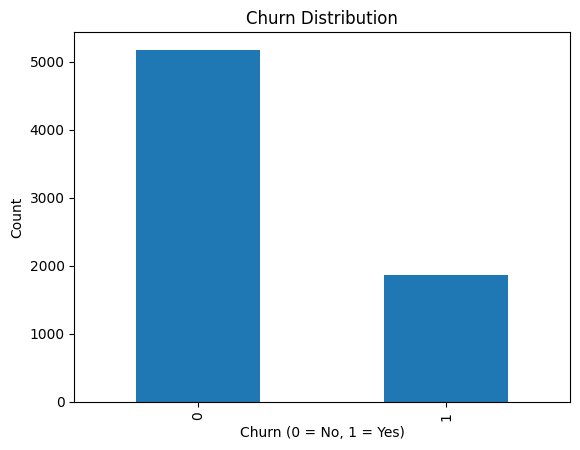

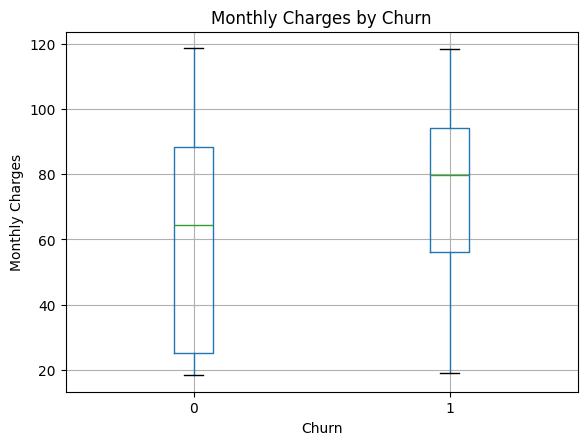

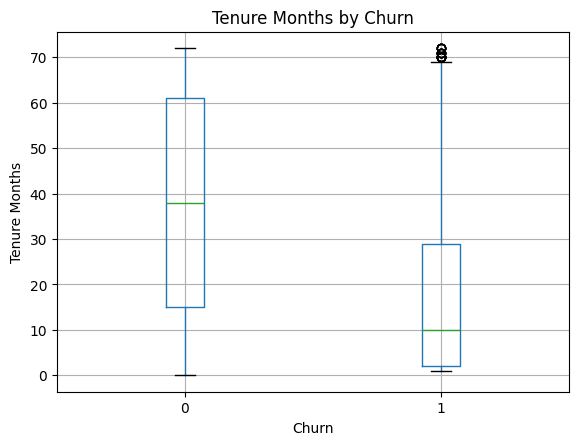

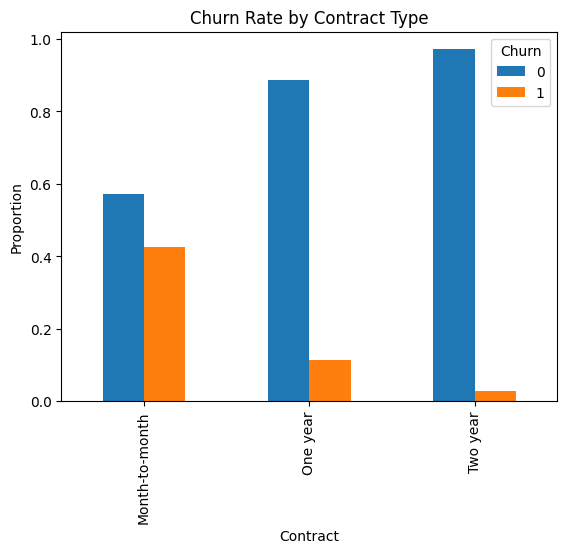

In [13]:
# Show data plots
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

df.boxplot(column="Monthly_Charges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

df.boxplot(column="Tenure_Months", by="Churn")
plt.title("Tenure Months by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.show()

pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

In [14]:
# Encode variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("New shape:", df_encoded.shape)
df_encoded.head()

# Split data
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

New shape: (7043, 31)
Training set: (5634, 30)
Test set: (1409, 30)


Logistic Regression Results
Accuracy: 0.7423704755145494
Precision: 0.5093062605752962
Recall: 0.8048128342245989
F1 Score: 0.6238341968911917

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



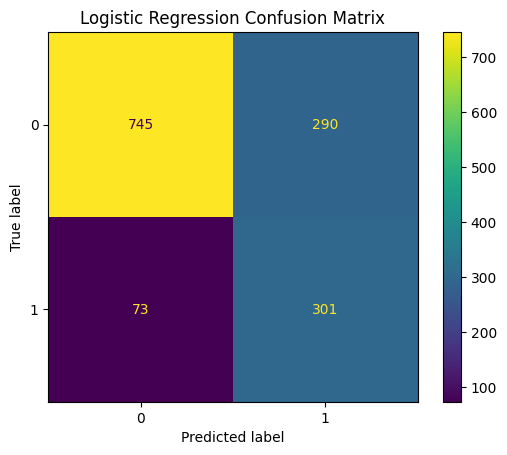

,Feature,Coefficient,Abs
0,Tenure_Months,-1.332592,1.332592
6,Dependents_Yes,-0.669881,0.669881
2,Total_Charges,0.621014,0.621014
25,Contract_Two year,-0.602110,0.602110
10,Internet_Service_Fiber optic,0.471838,0.471838
1,Monthly_Charges,-0.437966,0.437966
24,Contract_One year,-0.309431,0.309431
28,Payment_Method_Electronic check,0.201965,0.201965
9,Multiple_Lines_Yes,0.172553,0.172553
21,Streaming_TV_Yes,0.170024,0.170024


In [15]:
# Model 1: Logistic Regression
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Feature Importance
log_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance["Abs"] = log_importance["Coefficient"].abs()
log_importance = log_importance.sort_values(by="Abs", ascending=False)

log_importance.head(15)

Random Forest Results
Accuracy: 0.7927608232789212
Precision: 0.6443661971830986
Recall: 0.4893048128342246
F1 Score: 0.5562310030395137

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



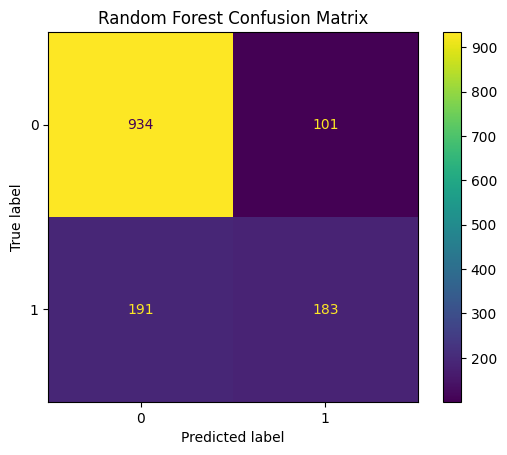

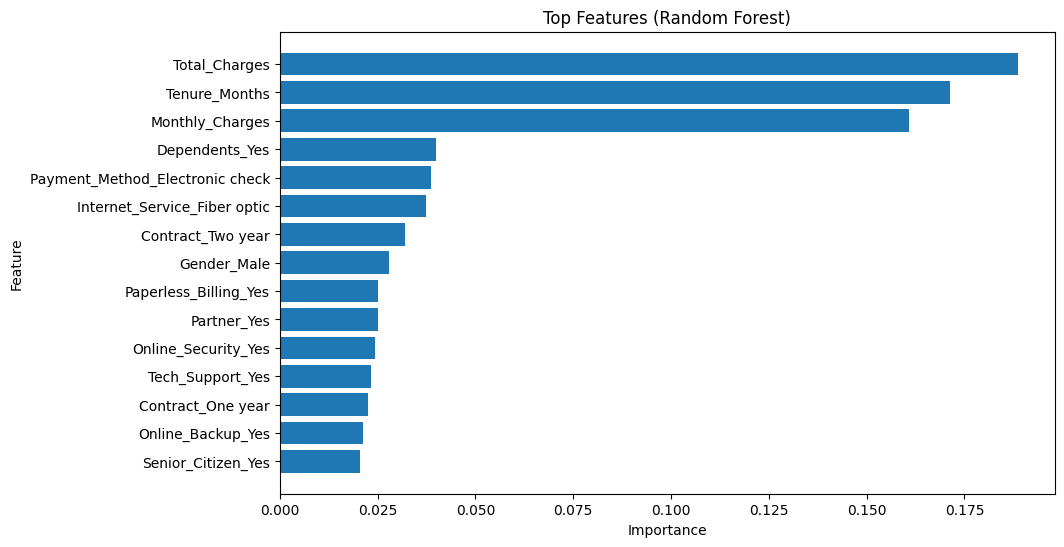

In [16]:
# Model 2: Random Forest
# Train Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Evaluate Model
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)
rf_importance.head(15)

top_rf = rf_importance.head(15).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.title("Top Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [17]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.742370,0.509306,0.804813,0.623834
1,Random Forest,0.792761,0.644366,0.489305,0.556231


In [10]:
# Interpretation:
# Logistic Regression:
# Positive coefficients increase likelihood of churn.
# Negative coefficients decrease likelihood of churn.
#
# Random Forest:
# Higher importance means the feature had more influence on predictions.